# WikiText-2 Core-6 MoE benchmark (v2)

This notebook is independent of the full 13-method notebook and writes to its own output directory. It compares only FC-Hybrid, MoEfication, EMoE, LLaMA-MoE random, LLaMA-MoE clustering, and the Regular Switch iso-total baseline.

`formal_fast` preserves the 2,000-update training budget while reducing repeated interim validation. `legacy_exact` retains the old validation cadence for direct compatibility. `quick_gpu` preserves approximately the same number of training tokens with a larger batch and fewer optimizer updates; use it only for previewing because it is not directly comparable with the old batch-32 run.

In [1]:
from pathlib import Path
import sys
import importlib
import inspect
import time
import torch
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings("ignore")

cwd = Path.cwd().resolve()
candidates = []
for base in (cwd, *cwd.parents):
    candidates.extend([base, base / 'experiments' / '08_transformer_moe'])
PACKAGE_DIR = next(
    (p for p in candidates if (p / '__init__.py').exists() and (p / 'config.py').exists()),
    None,
)
if PACKAGE_DIR is None:
    raise RuntimeError('Cannot locate experiments/08_transformer_moe.')
if str(PACKAGE_DIR.parent) not in sys.path:
    sys.path.insert(0, str(PACKAGE_DIR.parent))
PACKAGE_NAME = PACKAGE_DIR.name

config_module = importlib.import_module(f'{PACKAGE_NAME}.config')
data_module = importlib.import_module(f'{PACKAGE_NAME}.data')
runner_module = importlib.import_module(f'{PACKAGE_NAME}.runner')
analysis_module = importlib.import_module(f'{PACKAGE_NAME}.analysis')

BenchmarkConfig = config_module.BenchmarkConfig
method_table = config_module.method_table
load_wikitext2 = data_module.load_wikitext2
assert_runtime_compatibility = runner_module.assert_runtime_compatibility
load_results = runner_module.load_results
resolve_device = runner_module.resolve_device
run_benchmark = runner_module.run_benchmark
aggregate_summary_v2 = analysis_module.aggregate_summary_v2
apply_publication_style = analysis_module.apply_publication_style
audit_results_v2 = analysis_module.audit_results_v2
early_learning_metrics_v2 = analysis_module.early_learning_metrics_v2
load_benchmark_results = analysis_module.load_benchmark_results
paired_comparisons_v2 = analysis_module.paired_comparisons_v2

apply_publication_style()
pd.set_option('display.max_columns', 80)
pd.set_option('display.max_colwidth', 160)

## Configuration

For a formal result, keep `SPEED_PROFILE='formal_fast'`. The progress bar counts actual optimizer steps and changes its description during construction, validation, and final evaluation.

In [ ]:
RUN_BENCHMARK = True
SMOKE = False
SAVE_MODELS = True
SHOW_PROGRESS = True
SPEED_PROFILE = 'formal_fast'  # 'formal_fast', 'legacy_exact', or 'quick_gpu'
ENABLE_TF32 = True

CORE_METHODS = (
    'fc_guided',
    'moefication',
    'emoe',
    'llama_moe_random',
    'llama_moe_clustering',
    'switch_partitioned',
)

if SPEED_PROFILE == 'formal_fast':
    speed = dict(
        batch_size=32, total_steps=2000, dense_warmup_steps=100,
        eval_interval=100, eval_batches=30, construction_batches=50,
        router_calibration_steps=50, router_alignment_steps=300,
        lr=5e-4, deterministic=True,
    )
elif SPEED_PROFILE == 'legacy_exact':
    speed = dict(
        batch_size=32, total_steps=2000, dense_warmup_steps=100,
        eval_interval=20, eval_batches=30, construction_batches=50,
        router_calibration_steps=50, router_alignment_steps=300,
        lr=5e-4, deterministic=True,
    )
elif SPEED_PROFILE == 'quick_gpu':
    # About the same training-token budget as formal_fast, but only half as many updates.
    speed = dict(
        batch_size=64, total_steps=1000, dense_warmup_steps=50,
        eval_interval=50, eval_batches=15, construction_batches=25,
        router_calibration_steps=25, router_alignment_steps=150,
        lr=7e-4, deterministic=False,
    )
else:
    raise ValueError("SPEED_PROFILE must be 'formal_fast', 'legacy_exact', or 'quick_gpu'")

use_tf32 = ENABLE_TF32 and SPEED_PROFILE != 'legacy_exact'
if torch.cuda.is_available():
    torch.set_float32_matmul_precision('high' if use_tf32 else 'highest')
    torch.backends.cuda.matmul.allow_tf32 = use_tf32
    torch.backends.cudnn.allow_tf32 = use_tf32

output_name = 'outputs_smoke_core6_v2' if SMOKE else f'outputs_{SPEED_PROFILE}_core6_v2'
# output_name = f'outputs_{SPEED_PROFILE}_core6_v2_hyperparameter_tuning'
cfg = BenchmarkConfig(
    data_dir='/mnt/Data16T/Data/haichao/code/AI_connectom/story/story_part2_struc_func/Transformer/data/wikitext-2',
    output_dir=str(PACKAGE_DIR / output_name),
    seq_len=128,
    batch_size=speed['batch_size'],
    max_vocab_size=5000,

    d_model=256,
    n_heads=4,
    d_ff=1024,
    n_layers=5,
    num_experts=4,
    top_k=1,
    dropout=0.1,
    tie_embeddings=False,
    embedding_init_std=0.02,
    xavier_initialize=True,
    capacity_factor=2.0,
    drop_overflow_tokens=True,

    lr=speed['lr'],
    weight_decay=0.01,
    total_steps=12 if SMOKE else speed['total_steps'],
    dense_warmup_steps=2 if SMOKE else speed['dense_warmup_steps'],
    eval_interval=4 if SMOKE else speed['eval_interval'],
    eval_batches=2 if SMOKE else speed['eval_batches'],
    restore_best_validation=True,
    construction_batches=1 if SMOKE else speed['construction_batches'],
    aux_loss_coef=0.1,
    grad_clip=5.0,

    router_calibration_steps=1 if SMOKE else speed['router_calibration_steps'],
    d2d_sparsity_steps=1 if SMOKE else 20,
    d2d_hoyer_alpha=1e-4,
    d2d_threshold=0.5,
    d2d_threshold_sweep=(0.0, 0.25, 0.5, 0.75, 0.9),
    router_hidden_size=128,
    router_calibration_temperature=1.0,
    router_alignment_coef=0.02,
    router_alignment_steps=3 if SMOKE else speed['router_alignment_steps'],

    fc_consensus_splits=4,
    fc_output_weight=0.5,
    fc_uniform_shrinkage=0.02,
    fc_refinement_swaps=128,
    fc_hybrid_view_weights=((1.00, 0.00, 0.00), (0.70, 0.15, 0.15),
                            (0.55, 0.25, 0.20), (0.40, 0.30, 0.30)),
    fc_oracle_tokens=4096,
    fc_router_ridge=0.05,
    fc_router_key_prior=0.20,

    cluster_aware_energy=0.90,
    cluster_aware_min_rank_fraction=0.50,
    cluster_aware_distill_coef=0.1,
    ema_decay=0.999,

    seeds=tuple(range(30)),
    methods=CORE_METHODS,
    device='auto',
    deterministic=speed['deterministic'],
)

cfg.validate()
runtime_report = assert_runtime_compatibility()
if 'show_progress' not in inspect.signature(run_benchmark).parameters:
    raise RuntimeError('A stale runner.py is loaded. Restart the Jupyter kernel and run all cells.')
print('runtime compatibility: PASS')
print('package:', PACKAGE_DIR)
print('output:', cfg.output_dir)
print('device:', resolve_device(cfg.device))
print('speed profile:', SPEED_PROFILE)
print('training tokens/method:', cfg.total_steps * cfg.batch_size * cfg.seq_len)
display(pd.DataFrame(method_table(cfg)))
display(pd.DataFrame([cfg.to_dict()]))

runtime compatibility: PASS
package: /mnt/Data16T/Data/haichao/code/AI_connectom/story/story_part2_struc_func/Transformer/MoE_benchmark_v2
output: /mnt/Data16T/Data/haichao/code/AI_connectom/story/story_part2_struc_func/Transformer/MoE_benchmark_v2/outputs_formal_fast_core6_v2_hyperparameter_tuning
device: cuda
speed profile: formal_fast
training tokens/method: 8192000


,name,label,regime,construction,router,expert_width,requires_dense,router_calibration,router_target,router_objective,router_initialization,joint_router_alignment,aux_loss_coef_override,sparsity_calibration,distillation,notes
0,fc_guided,FC-Hybrid (ours),partitioned_iso_total,fc_hybrid,switch,partitioned,True,False,reconstruction_score,soft_ce,oracle_ridge,True,0.01,False,False,"Calibration-selected blend of consensus FC, co-activation and key geometry, followed by oracle-reconstruction ridge router initialization."
1,moefication,MoEfication,partitioned_iso_total,coactivation,moefication_mlp,partitioned,True,True,positive_activation,mse,default,False,-1.00,False,False,Co-activation graph partition plus independently calibrated MLP selector.
2,emoe,EMoE,partitioned_iso_total,key_clustering,avg_key,partitioned,True,False,none,mse,default,False,-1.00,False,False,Constrained key clustering; gate is tied to expert mean keys.
3,llama_moe_random,LLaMA-MoE (random),partitioned_iso_total,random,switch,partitioned,True,False,none,mse,default,False,-1.00,False,False,
4,llama_moe_clustering,LLaMA-MoE (clustering),partitioned_iso_total,key_clustering,switch,partitioned,True,False,none,mse,default,False,-1.00,False,False,
5,switch_partitioned,Regular Switch (iso-total),partitioned_iso_total,scratch,switch,partitioned,False,False,none,mse,default,False,-1.00,False,False,From-scratch Switch control with d_ff / E hidden units per expert.


,data_dir,output_dir,seq_len,batch_size,max_vocab_size,d_model,n_heads,d_ff,n_layers,num_experts,top_k,dropout,tie_embeddings,embedding_init_std,xavier_initialize,capacity_factor,drop_overflow_tokens,lr,weight_decay,total_steps,dense_warmup_steps,eval_interval,eval_batches,restore_best_validation,construction_batches,aux_loss_coef,grad_clip,router_calibration_steps,d2d_sparsity_steps,d2d_hoyer_alpha,d2d_threshold,d2d_threshold_sweep,router_hidden_size,router_calibration_temperature,router_alignment_coef,router_alignment_steps,fc_consensus_splits,fc_output_weight,fc_uniform_shrinkage,fc_refinement_swaps,fc_hybrid_view_weights,fc_oracle_tokens,fc_router_ridge,fc_router_key_prior,cluster_aware_energy,cluster_aware_min_rank_fraction,cluster_aware_distill_coef,ema_decay,seeds,methods,device,deterministic
0,/mnt/Data16T/Data/haichao/code/AI_connectom/story/story_part2_struc_func/Transformer/data/wikitext-2,/mnt/Data16T/Data/haichao/code/AI_connectom/story/story_part2_struc_func/Transformer/MoE_benchmark_v2/outputs_formal_fast_core6_v2_hyperparameter_tuning,128,32,5000,256,4,1024,5,4,1,0.1,False,0.02,True,2.0,True,0.0005,0.01,2000,100,100,30,True,50,0.1,5.0,50,20,0.0001,0.5,"[0.0, 0.25, 0.5, 0.75, 0.9]",128,1.0,0.02,300,4,0.5,0.02,128,"((1.0, 0.0, 0.0), (0.7, 0.15, 0.15), (0.55, 0.25, 0.2), (0.4, 0.3, 0.3))",4096,0.05,0.2,0.9,0.5,0.1,0.999,"[0, 1]","[fc_guided, moefication, emoe, llama_moe_random, llama_moe_clustering, switch_partitioned]",auto,True


## Run benchmark

The bar may pause during validation because a validation pass contains multiple forward batches. Its description will explicitly say `validation` or `final evaluation` during those periods. Partial results are saved after every completed method.

In [3]:
data_root = Path(cfg.data_dir).expanduser()
if RUN_BENCHMARK and not data_root.exists():
    raise FileNotFoundError(f'Update cfg.data_dir; not found: {data_root}')

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
    props = torch.cuda.get_device_properties(0)
    print({'gpu': props.name, 'gpu_memory_GB': round(props.total_memory / 2**30, 2)})
started_at = time.perf_counter()
if RUN_BENCHMARK:
    bundle = load_wikitext2(cfg.data_dir, cfg.seq_len, cfg.max_vocab_size)
    print({
        'vocab': len(bundle.vocab.itos),
        'train_sequences': len(bundle.train),
        'valid_sequences': len(bundle.valid),
        'test_sequences': len(bundle.test),
    })
    summaries, histories = run_benchmark(
        bundle, cfg, save_models=SAVE_MODELS, show_progress=SHOW_PROGRESS
    )
else:
    summaries, histories = load_results(cfg.output_dir)
    print(f'Loaded {len(summaries)} completed runs from {cfg.output_dir}')
print(f'Elapsed: {(time.perf_counter() - started_at) / 3600:.2f} h')
if torch.cuda.is_available():
    total_memory = torch.cuda.get_device_properties(0).total_memory
    peak_memory = torch.cuda.max_memory_allocated()
    print({
        'peak_allocated_GB': round(peak_memory / 2**30, 3),
        'peak_allocated_percent': round(100 * peak_memory / total_memory, 2),
        'note': 'Low memory use alone does not imply low GPU compute utilization.',
    })

{'gpu': 'NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition', 'gpu_memory_GB': 94.97}
{'vocab': 5000, 'train_sequences': 16317, 'valid_sequences': 1700, 'test_sequences': 1918}


MoE benchmark training:   0%|          | 0/23200 [00:00<?, ?step/s]

Elapsed: 1.54 h
{'peak_allocated_GB': 0.806, 'peak_allocated_percent': 0.85, 'note': 'Low memory use alone does not imply low GPU compute utilization.'}


## Load and audit the isolated results

In [4]:
summary_df, history_df, saved_config, constructions = load_benchmark_results(cfg.output_dir)
expected = {(method, seed) for method in CORE_METHODS for seed in cfg.seeds}
observed = set(zip(summary_df['method'], summary_df['seed']))
if observed != expected:
    raise RuntimeError(f'Incomplete or contaminated result set. Missing={expected-observed}, extra={observed-expected}')
audit_df = audit_results_v2(summary_df, history_df, saved_config)
# The generic v2 audit contains construction-only checks for matched-ridge controls,
# which are intentionally absent here. Replace them with a Core-6 compute check.
audit_df = audit_df[~audit_df['check'].str.startswith('primary construction')].copy()
fc_flops = summary_df.loc[summary_df['method'] == 'fc_guided', ['seed', 'measured_expert_flops_per_token']]
ratios = summary_df.merge(fc_flops, on='seed', suffixes=('', '_fc'))
ratios['ratio_vs_fc'] = ratios['measured_expert_flops_per_token'] / ratios['measured_expert_flops_per_token_fc']
max_compute_deviation = float((ratios['ratio_vs_fc'] - 1.0).abs().max())
core_compute_row = pd.DataFrame([{
    'check': 'Core-6 measured expert-compute match',
    'status': 'PASS' if max_compute_deviation <= 0.10 else 'WARN',
    'detail': f'maximum deviation from FC-Hybrid = {100 * max_compute_deviation:.1f}%',
}])
audit_df = pd.concat([audit_df, core_compute_row], ignore_index=True)
display(audit_df)

,check,status,detail
0,required summary fields,PASS,all present
1,one row per method × seed,PASS,no duplicates
2,method × seed completeness,PASS,12/12 expected pairs
3,finite reported metrics,PASS,all finite
4,equal charged training tokens within seed,PASS,seed 0: 1 unique value(s); seed 1: 1 unique value(s)
5,replicate count for inference,WARN,minimum n=2 seed(s); paired points and effect sizes are primary when n<5
6,token dropping below 5%,PASS,maximum dropped-token fraction = 0.5%
7,unclipped learning-curve display,PASS,use validation NLL: 0 point(s) hit the exp(20) perplexity cap
8,Core-6 measured expert-compute match,PASS,maximum deviation from FC-Hybrid = 0.5%


## Final metrics and FC-Hybrid comparisons

In the comparison table, a positive `delta_ppl_competitor_minus_fc` means FC-Hybrid has lower perplexity.

In [5]:
aggregate_df = aggregate_summary_v2(summary_df)
comparison_df = paired_comparisons_v2(
    summary_df, baseline='fc_guided', methods=[m for m in CORE_METHODS if m != 'fc_guided']
)
result_columns = [
    'method', 'label', 'n_seeds', 'test_perplexity_mean',
    'test_perplexity_sem', 'valid_perplexity_mean',
    'total_parameters_mean', 'measured_active_parameters_mean',
    'measured_expert_flops_per_token_mean', 'mean_selected_experts_mean',
    'mean_dropped_fraction_mean', 'elapsed_seconds_mean',
]
display(aggregate_df[result_columns].sort_values('test_perplexity_mean'))
display(comparison_df)
early_df = early_learning_metrics_v2(history_df, start_step=100, end_step=500)
display(early_df)

,method,label,n_seeds,test_perplexity_mean,test_perplexity_sem,valid_perplexity_mean,total_parameters_mean,measured_active_parameters_mean,measured_expert_flops_per_token_mean,mean_selected_experts_mean,mean_dropped_fraction_mean,elapsed_seconds_mean
0,fc_guided,FC-Hybrid (ours),2,47.858252,0.081994,51.333219,6547200.0,4.577280e+06,655360.000000,1.000000,0.000000,1146.628897
2,emoe,EMoE,2,48.216508,0.064802,51.715441,6542080.0,4.569051e+06,652257.301356,0.995266,0.004729,305.858332
3,llama_moe_random,LLaMA-MoE (random),2,48.858087,0.258046,52.361135,6547200.0,4.577280e+06,655360.000000,1.000000,0.000000,268.827376
4,llama_moe_clustering,LLaMA-MoE (clustering),2,48.940832,0.447791,52.453856,6547200.0,4.577280e+06,655360.000000,1.000000,0.000000,311.656836
1,moefication,MoEfication,2,48.950508,0.357301,52.436407,6709140.0,4.739220e+06,655360.000000,1.000000,0.000000,362.825906
5,switch_partitioned,Regular Switch (iso-total),2,50.729130,0.340297,54.400768,6547200.0,4.577280e+06,655360.000000,1.000000,0.000000,273.180495


,baseline,method,comparison_scope,n_pairs,delta_ppl_competitor_minus_fc,delta_sem,delta_ci95_low,delta_ci95_high,fc_wins,p_value_paired_t,measured_expert_flops_ratio_vs_fc,p_holm_all_partitioned,p_holm_construction_only
0,fc_guided,moefication,adaptation/control,2,1.092255,0.275307,-2.405848,4.590358,2,0.157188,1.000000,0.371906,NaN
1,fc_guided,emoe,adaptation/control,2,0.358255,0.017192,0.139814,0.576697,2,0.030526,0.995266,0.152632,NaN
2,fc_guided,llama_moe_random,adaptation/control,2,0.999835,0.176052,-1.237112,3.236782,2,0.110959,1.000000,0.371906,NaN
3,fc_guided,llama_moe_clustering,adaptation/control,2,1.082580,0.365797,-3.565314,5.730473,2,0.207442,1.000000,0.371906,NaN
4,fc_guided,switch_partitioned,adaptation/control,2,2.870878,0.422291,-2.494835,8.236590,2,0.092977,1.000000,0.371906,NaN


,method,seed,window_first_step,window_last_step,n_evaluations,mean_valid_nll,normalized_nll_auc,last_valid_nll
0,emoe,0,101,500,5,4.830656,4.806868,4.530612
1,emoe,1,101,500,5,4.839019,4.817873,4.516210
2,fc_guided,0,101,500,5,4.815290,4.794827,4.513938
3,fc_guided,1,101,500,5,4.850064,4.827423,4.512477
4,llama_moe_clustering,0,101,500,5,4.835306,4.812487,4.533753
5,llama_moe_clustering,1,101,500,5,4.875870,4.852235,4.546605
6,llama_moe_random,0,101,500,5,4.908790,4.866685,4.561243
7,llama_moe_random,1,101,500,5,4.934685,4.899089,4.577371
8,moefication,0,151,500,5,4.872822,4.822148,4.566482
9,moefication,1,151,500,5,4.925028,4.869733,4.588583


## Analysis plots

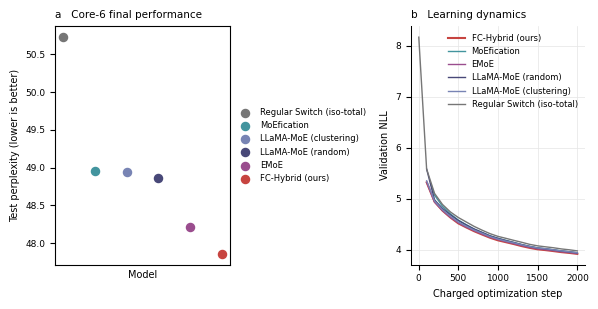

In [6]:
import numpy as np
analysis_dir = Path(cfg.output_dir) / 'analysis_core6_v2'
analysis_dir.mkdir(parents=True, exist_ok=True)

label_map = summary_df.drop_duplicates('method').set_index('method')['label'].to_dict()
colors = {
    'fc_guided': '#C74440', 'moefication': '#42949E', 'emoe': '#9A4D8E',
    'llama_moe_random': '#484878', 'llama_moe_clustering': '#7884B4',
    'switch_partitioned': '#767676',
}
fig, axes = plt.subplots(1, 2, figsize=(6, 3.1))

ordered = aggregate_df.sort_values('test_perplexity_mean', ascending=False).reset_index(drop=True)
x = np.arange(len(ordered))
for i, row in ordered.iterrows():
    axes[0].scatter(
        i, row['test_perplexity_mean'], color=colors[row['method']],
        s=34, label=row['label'], zorder=3,
    )
axes[0].set_xticks([])
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Test perplexity (lower is better)')
axes[0].set_title('a   Core-6 final performance', loc='left')
# axes[0].grid(axis='y', color='#DDDDDD', linewidth=0.6)
for spine in axes[0].spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)
axes[0].legend(
    frameon=False, fontsize=6, loc='center left',
    bbox_to_anchor=(1.02, 0.5), borderaxespad=0,
)

for method in CORE_METHODS:
    curve = history_df[history_df['method'] == method]
    curve = curve.groupby('global_step', as_index=False)['valid_loss'].mean()
    axes[1].plot(
        curve['global_step'], curve['valid_loss'], label=label_map[method],
        color=colors[method], linewidth=1.5 if method == 'fc_guided' else 1.0,
    )
axes[1].set_xlabel('Charged optimization step')
axes[1].set_ylabel('Validation NLL')
axes[1].set_title('b   Learning dynamics', loc='left')
axes[1].legend(frameon=False, fontsize=6)
axes[1].grid(color='#E5E5E5', linewidth=0.5)

fig.subplots_adjust(wspace=0.75)
fig.tight_layout()
for suffix in ('png', 'pdf', 'svg'):
    fig.savefig(analysis_dir / f'core6_benchmark_v2.{suffix}', dpi=300, bbox_inches='tight')
plt.show()

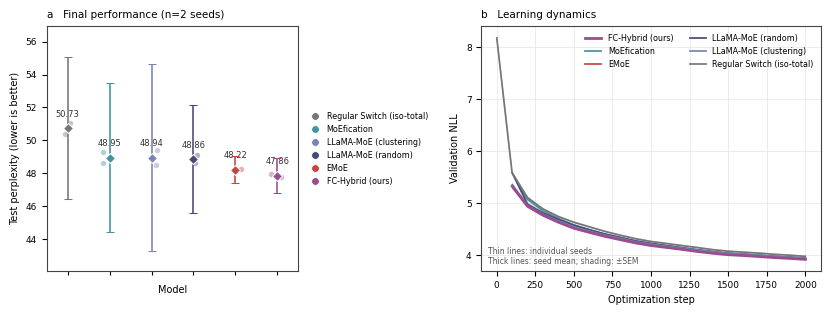

In [7]:
import numpy as np
from matplotlib.lines import Line2D

analysis_dir = Path(cfg.output_dir) / 'analysis_core6_v2'
analysis_dir.mkdir(parents=True, exist_ok=True)

label_map = summary_df.drop_duplicates('method').set_index('method')['label'].to_dict()

colors = {
    'emoe': '#C74440',
    'moefication': '#42949E',
    'fc_guided': '#9A4D8E',
    'llama_moe_random': '#484878',
    'llama_moe_clustering': '#7884B4',
    'switch_partitioned': '#767676',
}

seed_values = sorted(summary_df['seed'].unique())
fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.35), gridspec_kw={'width_ratios': [1.0, 1.35]})

# ============================================================
# a | Test perplexity:
#     jittered seed points + mean ± 95% CI
# ============================================================

ordered = aggregate_df.sort_values('test_perplexity_mean', ascending=False).reset_index(drop=True)
x_positions = np.arange(len(ordered))
rng = np.random.default_rng(0)
all_y_values = []

for xi, row in ordered.iterrows():
    method = row['method']
    method_color = colors[method]
    raw = summary_df.loc[summary_df['method'] == method, ['seed', 'test_perplexity']].dropna()
    y = raw['test_perplexity'].to_numpy(dtype=float)
    x = xi + rng.uniform(-0.16, 0.16, size=len(y))
    all_y_values.extend(y.tolist())

    if len(y) > 0:
        axes[0].vlines(xi, y.min(), y.max(), color=method_color, linewidth=1.0, alpha=0.16, zorder=1)
        axes[0].scatter(x, y, s=16, facecolor=method_color, edgecolor='white', linewidth=0.35, alpha=0.42, zorder=2)

    mean = float(row['test_perplexity_mean'])
    ci_low = float(row['test_perplexity_ci95_low'])
    ci_high = float(row['test_perplexity_ci95_high'])
    all_y_values.extend([ci_low, ci_high])

    if np.isfinite(ci_low) and np.isfinite(ci_high):
        axes[0].errorbar(
            xi, mean, yerr=np.array([[mean - ci_low], [ci_high - mean]]), fmt='D',
            color=method_color, markerfacecolor=method_color, markeredgecolor='white',
            markeredgewidth=0.75, markersize=5.4, capsize=3, capthick=1.0, elinewidth=1.15, zorder=4
        )
    else:
        axes[0].scatter(xi, mean, marker='D', s=36, color=method_color, edgecolor='white', linewidth=0.75, zorder=4)

    axes[0].annotate(
        f'{mean:.2f}', xy=(xi, mean), xytext=(0, 7), textcoords='offset points',
        va='bottom', ha='center', fontsize=6.0, color='#333333'
    )

axes[0].set_xlim(-0.5, len(ordered) - 0.5)
axes[0].set_xticks(x_positions)
axes[0].set_xticklabels([''] * len(x_positions))
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Test perplexity (lower is better)')
axes[0].set_title(f'a   Final performance (n={len(seed_values)} seeds)', loc='left')
axes[0].tick_params(axis='x', length=3)
# axes[0].grid(axis='y', color='#E6E6E6', linewidth=0.6)
axes[0].set_axisbelow(True)

finite_y = np.asarray(all_y_values, dtype=float)
finite_y = finite_y[np.isfinite(finite_y)]
if finite_y.size:
    y_range = max(0.4, finite_y.max() - finite_y.min())
    axes[0].set_ylim(finite_y.min() - 0.10 * y_range, finite_y.max() + 0.16 * y_range)

method_handles = [
    Line2D([0], [0], marker='o', linestyle='none', markerfacecolor=colors[m], markeredgecolor='white',
           markeredgewidth=0.5, markersize=5.5, label=label_map[m])
    for m in ordered['method']
]

axes[0].legend(
    handles=method_handles, frameon=False, fontsize=5.8, loc='center left',
    bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0, handletextpad=0.5
)

# ============================================================
# b | Learning dynamics:
#     individual seed curves + seed-averaged curve
# ============================================================

for method in CORE_METHODS:
    method_history = history_df.loc[history_df['method'] == method, ['seed', 'global_step', 'valid_loss']].dropna().sort_values(['seed', 'global_step'])

    for seed, seed_curve in method_history.groupby('seed'):
        axes[1].plot(
            seed_curve['global_step'], seed_curve['valid_loss'],
            color=colors[method], linewidth=0.7, alpha=0.18, zorder=1
        )

    mean_curve = (
        method_history
        .groupby('global_step', as_index=False)
        .agg(valid_loss_mean=('valid_loss', 'mean'), valid_loss_sem=('valid_loss', 'sem'), n_seeds=('seed', 'nunique'))
        .sort_values('global_step')
    )

    axes[1].plot(
        mean_curve['global_step'], mean_curve['valid_loss_mean'],
        label=label_map[method], color=colors[method],
        linewidth=2.0 if method == 'fc_guided' else 1.25,
        zorder=3 if method == 'fc_guided' else 2
    )

    sem = mean_curve['valid_loss_sem'].fillna(0).to_numpy()
    mean_nll = mean_curve['valid_loss_mean'].to_numpy()
    steps = mean_curve['global_step'].to_numpy()

    axes[1].fill_between(
        steps, mean_nll - sem, mean_nll + sem,
        color=colors[method], alpha=0.08 if method != 'fc_guided' else 0.12,
        linewidth=0, zorder=0
    )

axes[1].set_xlabel('Optimization step')
axes[1].set_ylabel('Validation NLL')
axes[1].set_title('b   Learning dynamics', loc='left')
axes[1].grid(color='#E5E5E5', linewidth=0.5)
axes[1].set_axisbelow(True)
axes[1].legend(frameon=False, fontsize=5.8, ncol=2, loc='upper right')
axes[1].text(
    0.02, 0.02, 'Thin lines: individual seeds\nThick lines: seed mean; shading: ±SEM',
    transform=axes[1].transAxes, fontsize=5.5, va='bottom', ha='left', color='#555555'
)

for ax in axes:
    for side in ['top', 'right', 'bottom', 'left']:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(0.8)
        ax.spines[side].set_color('#444444')

fig.subplots_adjust(left=0.08, right=0.98, bottom=0.17, top=0.90, wspace=0.62)

for suffix in ('png', 'pdf', 'svg'):
    fig.savefig(analysis_dir / f'core6_benchmark_v2.{suffix}', dpi=300, bbox_inches='tight')

plt.show()

48.22
47.86

## Export source tables

In [8]:
source_dir = analysis_dir / 'source_data'
source_dir.mkdir(parents=True, exist_ok=True)
tables = {
    'summary_by_seed.csv': summary_df,
    'summary_aggregate.csv': aggregate_df,
    'learning_history.csv': history_df,
    'fairness_audit.csv': audit_df,
    'paired_comparisons.csv': comparison_df,
    'early_learning_metrics.csv': early_df,
}
for name, table in tables.items():
    path = source_dir / name
    table.to_csv(path, index=False)
    print(path)

/mnt/Data16T/Data/haichao/code/AI_connectom/story/story_part2_struc_func/Transformer/MoE_benchmark_v2/outputs_formal_fast_core6_v2_hyperparameter_tuning/analysis_core6_v2/source_data/summary_by_seed.csv
/mnt/Data16T/Data/haichao/code/AI_connectom/story/story_part2_struc_func/Transformer/MoE_benchmark_v2/outputs_formal_fast_core6_v2_hyperparameter_tuning/analysis_core6_v2/source_data/summary_aggregate.csv
/mnt/Data16T/Data/haichao/code/AI_connectom/story/story_part2_struc_func/Transformer/MoE_benchmark_v2/outputs_formal_fast_core6_v2_hyperparameter_tuning/analysis_core6_v2/source_data/learning_history.csv
/mnt/Data16T/Data/haichao/code/AI_connectom/story/story_part2_struc_func/Transformer/MoE_benchmark_v2/outputs_formal_fast_core6_v2_hyperparameter_tuning/analysis_core6_v2/source_data/fairness_audit.csv
/mnt/Data16T/Data/haichao/code/AI_connectom/story/story_part2_struc_func/Transformer/MoE_benchmark_v2/outputs_formal_fast_core6_v2_hyperparameter_tuning/analysis_core6_v2/source_data/pai